In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
from itertools import combinations
import random
from sklearn.metrics import adjusted_rand_score
import math

In [ ]:
def new_fvec(G):
    #AM = nx.adjacency_matrix(G)
    #NLM = (nx.normalized_laplacian_matrix(G)).todense()
    LM = (nx.laplacian_matrix(G)).todense()

    LMva, LMve = np.linalg.eigh(LM)

    Fv = LMve[:,1]

    return [Fv.item(x) for x in range(len(G.nodes()))],LMva[1],LM
def fiedsimilarity(vec, othervec):
    trueclusters = [str(vec[i]<0) for i in range(len(vec))]
    possclusters = [0 for i in range(len(othervec))]
    for i in othervec:
        if i<0:
            possclusters[othervec.index(i)] += 0
        else:
            possclusters[othervec.index(i)] += 1
    return adjusted_rand_score(trueclusters,possclusters)
def spec(graph):
    return np.linalg.eigh(nx.laplacian_matrix(graph).todense())

# Monte Carlo
To estimate whatever we want, oftentimes we can simply randomly sample!

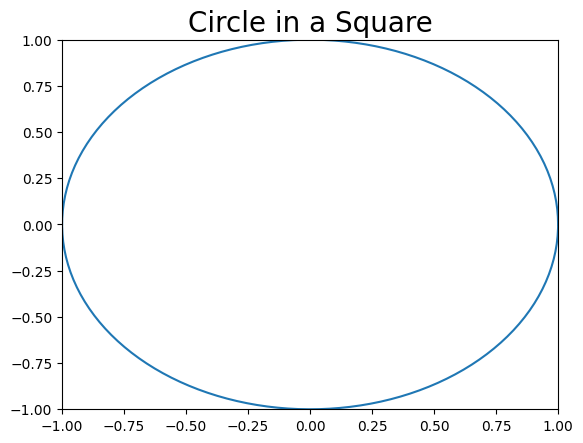

In [ ]:
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta))
plt.title("Circle in a Square",fontsize=20)
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.show()

In [ ]:
def montecircle(n):
    # make random points

    x = np.random.uniform(-1, 1, n)
    y = np.random.uniform(-1, 1, n)

    # determine inside

    inside = (x**2+y**2)<= 1
    plt.scatter(x[inside], y[inside], s=5, label="Accepted")
    plt.scatter(x[~inside], y[~inside], s=5, label="Rejected")

    #plotting

    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta))
    plt.title("Monte Carlo on the Circle")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    #compute pi

    pi = 4*np.mean(inside)
    print('Pi is about: ',pi)


Generate 10000 uniformly random samples in the square and reject if they are outside the circle.

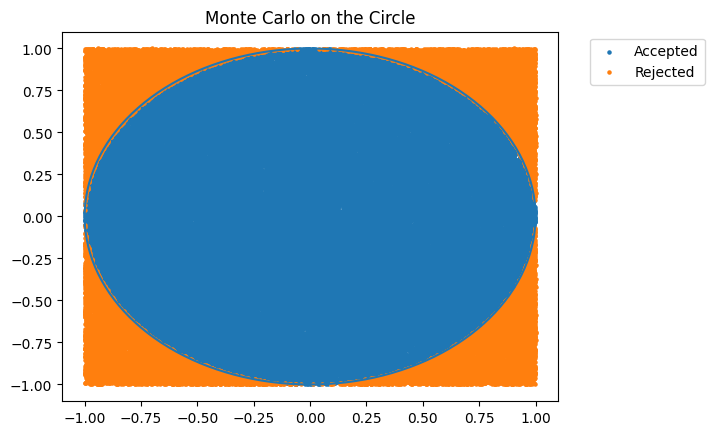

Pi is about:  3.14352


In [ ]:
montecircle(100000)

But, nobody likes points. Everybody likes graphs.<br>
To generate random graphs, a classic choice is the Erd\"os-Renyi Graph model.

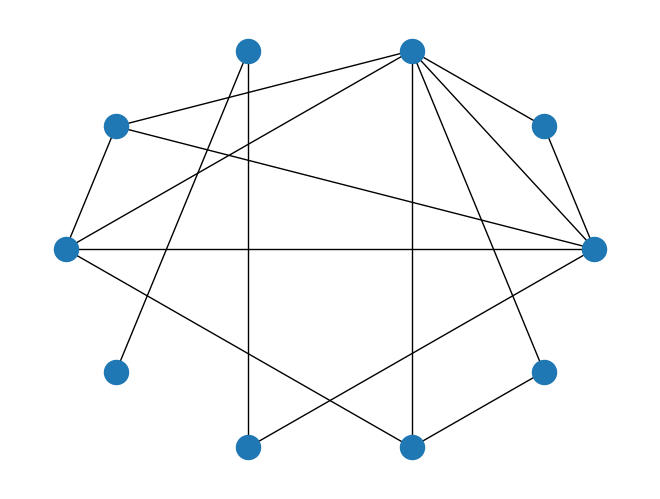

In [ ]:
n = 10
p = .25
graph = nx.erdos_renyi_graph(n,p)
nx.draw_circular(graph)

Maybe we want to approximate a given graph.

In [ ]:
cycle = nx.cycle_graph(20)
spectral = spec(cycle)
fiedval = spectral[0][1]
print('Known Eigenvalue: '+str(fiedval))

In [ ]:
def monteeigval(nsteps, goal, p, epsilon):
    # define goal

    n = len(goal.nodes())
    fiedval = spec(goal)[0][1]


    sampledgraphs = []
    inside = []
    outside = []
    for i in range(nsteps):

        # propose new state

        graph = nx.erdos_renyi_graph(n,p)
        graphfied = spec(graph)[0][1]

        # reject if disconnected

        if nx.is_connected(graph) == True:

            # accept if fiedler value inside epsilon ball reject otherwise

            if abs(graphfied - fiedval)<epsilon:
                inside.append(graphfied)
                sampledgraphs.append(graph)

            else:
                outside.append(graphfied)

        else:
            outside.append(graphfied)
    width = 1
    plt.hist([inside,outside],histtype = 'barstacked', bins=30, label=['Accepted', 'Rejected'], align='mid')
    plt.axvline(fiedval, color='red', label='Goal Eigenvalue')
    plt.xlabel('Sampled Fiedler Value')
    plt.ylabel('Frequency')
    plt.title('Accept-Reject on Second Eigenvalue')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
monteeigval(1000, cycle, .3,.5)

## Law of Large Numbers
The WLLN applies to random graph models as well!

In [ ]:
graph = nx.erdos_renyi_graph(10,.5)
len(graph.edges())

25

In [ ]:
nsteps = 1000
n = 20
p = .5

exp = (n*(n-1)/2)*p
avgs = [0]
avg = 0
for i in range(1,nsteps):
    graph = nx.erdos_renyi_graph(n,p)
    avg+=(len(graph.edges())-avg)/i
    avgs.append(avg)
print("Should converge to something around "+str(exp))

Should converge to something around 95.0


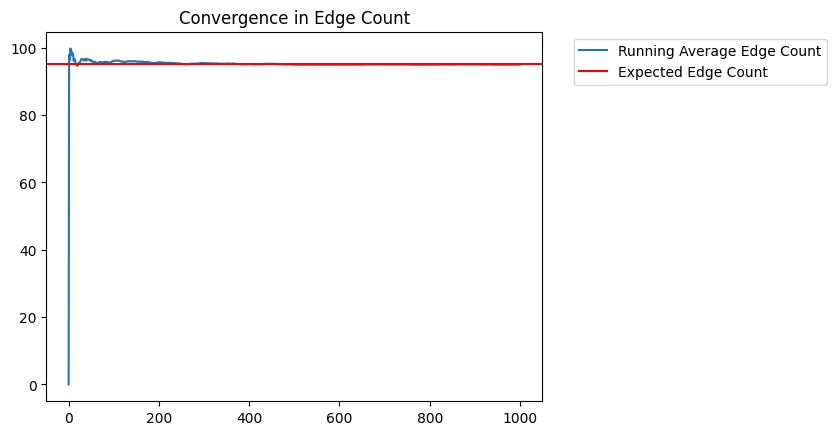

In [ ]:
plt.title('Convergence in Edge Count')
plt.plot(avgs, label='Running Average Edge Count')
plt.axhline(exp,color='red', label='Expected Edge Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

This even applies to values we do $not$ preciesly know. E.g. the average Fiedler value:

In [ ]:
nsteps = 1000
n = 20
p = .5
avgs = [0]
avg = 0
for i in range(1,nsteps):
    graph = nx.erdos_renyi_graph(n,p)
    avg+=(spec(graph)[0][1]-avg)/i
    avgs.append(avg)
print("Should converge to something around "+str(np.mean(avgs)))

Should converge to something around 4.608485894753055


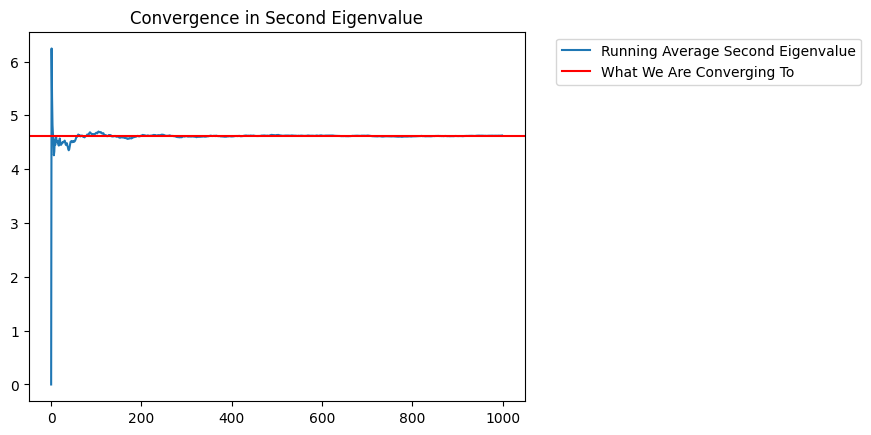

In [ ]:
plt.title('Convergence in Second Eigenvalue')
plt.plot(avgs, label='Running Average Second Eigenvalue')
plt.axhline(np.mean(avgs),color='red', label='What We Are Converging To')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Markov Chain Monte Carlo
What if we $really$ wanted $some$ points, but not so much others. What we'll do is weight the regions of the circle based on your responses.

In [ ]:
def density(values):
    return np.array([values.count(i) for i in list(set(values))])/len(values)

In [ ]:
def region(x, y):
    if x**2+y**2<=1:     # in circle
        return 0
    if x>=0 and y>=0: # top left
        return 1
    elif x<0 and y>= 0: #top right
        return 2
    elif x<0 and y<0: #bottom left
        return 3
    else:                 # bottom right
        return 4
def mcmccircle(nsteps, target, step_size=0.2):
    x, y = 0.0, 0.0  # start at center
    samples = []

    for i in range(nsteps):
        xprop = x +np.random.normal(0, step_size)
        yprop = y +np.random.normal(0, step_size)
        if not (-1 <= xprop <= 1 and -1 <= yprop <= 1):
            samples.append((x, y))
            continue
        rcurrent = region(x, y)
        rprop = region(xprop, yprop)
        alpha = min(1, target[rprop] / target[rcurrent])

        if np.random.rand() < alpha:
            x, y = xprop, yprop

        samples.append((x, y))

    return np.array(samples)

In [ ]:
def plotmcmc(samples):
    x = samples[:,0]
    y = samples[:,1]
    colors = []
    for i, j in zip(x, y):
        colors.append(region(i, j))
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c=colors, s=5)
    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta))

    plt.title("MCMC on the Circle")
    plt.xlim([-1,1])
    plt.ylim([-1,1])
    plt.show()

In [ ]:
values = [4,5,1,3,3,2,5,2,4,4,3]
target = [.01,.01,.01,.07,.9]
print(target)

[0.01, 0.01, 0.01, 0.07, 0.9]


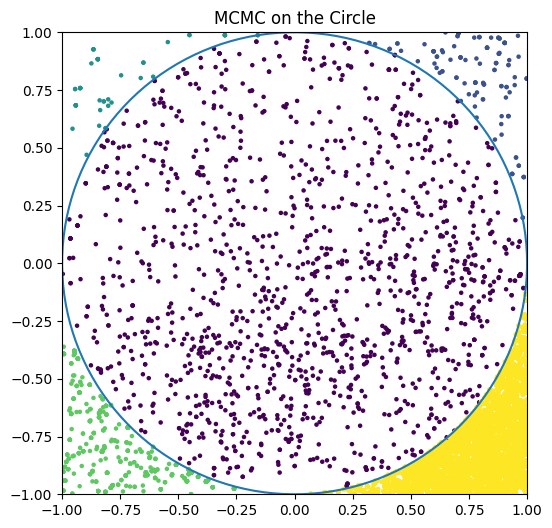

In [ ]:
plotmcmc(mcmccircle(10000, target))

In [ ]:

start = time.time()
goalgraph = nx.cycle_graph(10)

n = len(goalgraph.nodes())
vector,value,laplacian = new_fvec(goalgraph)
totalmcmcsim = []
totalmcmctrans = []
totalmcmcfiedval = []
totaledges = list(combinations([i for i in range(n)],2))
nk = len(totaledges)

graph = nx.erdos_renyi_graph(n,.4)
while nx.is_connected(graph) == False:
    graph = nx.erdos_renyi_graph(n,.4)
unisim = []
unifiedval = []
for i in range(1000):

    vec1,val1,lap = new_fvec(graph) # untoggled edge fiedler vector
    k = random.randint(1,nk)
    edges = random.sample(totaledges,k)
    removededges = []
    addededges = []
    for m in edges:
        if ((m[0],m[1]) in graph.edges()) or ((m[1],m[0]) in graph.edges()):
            graph.remove_edge(m[0],m[1])
            removededges.append((m[0],m[1]))
        else: #if edge not there
            graph.add_edge(m[0],m[1])
            addededges.append((m[0],m[1]))
    if nx.is_connected(graph)==True:
        vec2, val2, lap  = new_fvec(graph) # toggled fiedler

        score1 = fiedsimilarity(vector,vec1) # norm without toggle fiedler
        score2 = fiedsimilarity(vector,vec2) # norm with toggle fiedler
        lis = [1,math.e**((score2-score1)/.01)]
        alpha = min(lis) # alpha

        b = random.random() # beta

        if b <= alpha: # transition calculation
            unisim.append(score2)
            unifiedval.append(val2)
        else:
            graph.remove_edges_from(addededges)
            graph.add_edges_from(removededges)

    else:
        graph.remove_edges_from(addededges)
        graph.add_edges_from(removededges)
    if i%100==0:
        print("Step "+str(i))
totalmcmcsim.append(unisim)
totalmcmcfiedval.append(unifiedval)
print(time.time()-start)

Step 0
Step 100
Step 200
Step 300
Step 400
Step 500
Step 600
Step 700
Step 800
Step 900
4.026480436325073


(array([ 3.,  6.,  0.,  8.,  0.,  0., 14.,  0.,  0., 16.]),
 array([-0.05882353,  0.04705882,  0.15294118,  0.25882353,  0.36470588,
         0.47058824,  0.57647059,  0.68235294,  0.78823529,  0.89411765,
         1.        ]),
 <BarContainer object of 10 artists>)

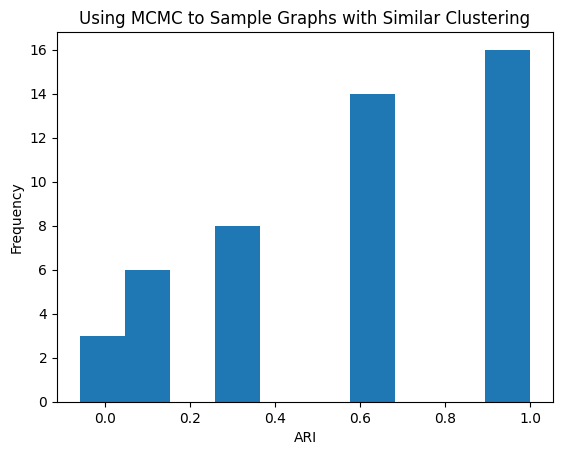

In [ ]:
plt.title('Using MCMC to Sample Graphs with Similar Clustering')
plt.xlabel('ARI')
plt.ylabel('Frequency')
plt.hist(unisim)

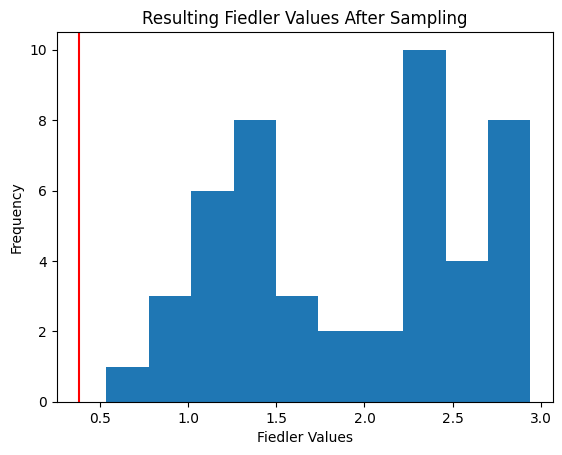

In [ ]:
plt.title('Resulting Fiedler Values After Sampling')
plt.xlabel('Fiedler Values')
plt.ylabel('Frequency')
plt.hist(unifiedval, label='Sampled Fiedler Values')
plt.axvline(value, color='red', label='Known Fiedler Value')